# SampleRepertoire — Overview

Loads multi-locus paired immune repertoires from the `isalgo/airr_benchmark`
SRA tarball and visualises the per-chain composition of each sample as two
stacked bar charts:

* **Top** — total read count (`duplicate_count`) per locus per sample
* **Bottom** — unique clonotype count per locus per sample

Data source: `airr_benchmark/sra/samples.tar.gz`
Metadata: `airr_benchmark/sra/meta.tsv` (columns: `PMID`, `Run`, `BioProject`, `Sample`)

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import io
import tarfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

from mir.common.clonotype import Clonotype
from mir.common.repertoire import SampleRepertoire, infer_locus
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_sra_meta

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["sra/**"])
TARBALL, META_CSV = find_airr_benchmark_sra_meta(benchmark_root)

# Loci shown in the plot (ordered and coloured consistently)
LOCI_ORDER = ["TRA", "TRB", "TRG", "TRD", "IGH", "IGK", "IGL"]
LOCI_COLORS = {
    "TRA": "#4e79a7",
    "TRB": "#f28e2b",
    "TRG": "#59a14f",
    "TRD": "#76b7b2",
    "IGH": "#e15759",
    "IGK": "#b07aa1",
    "IGL": "#ff9da7",
}

# Number of samples to visualise
N_SAMPLES = 30

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1099.57it/s]


## Load SampleRepertoires

Each TSV in the tarball follows the AIRR Rearrangement Schema with `v_call` / `j_call` columns.  
Locus is inferred from the gene prefix (`TRBV…` → `TRB`, `TRAV…` → `TRA`, etc.).

In [7]:
_CALL_RENAMES = {"v_call": "v_gene", "j_call": "j_gene", "c_call": "c_gene"}


def _extract_run_bytes(tar: tarfile.TarFile, run_id: str) -> bytes | None:
    """Return raw bytes for *run_id*.tsv from *tar*, or None if not present."""
    for candidate in (f"./{run_id}.tsv", f"{run_id}.tsv", run_id):
        try:
            member = tar.getmember(candidate)
        except KeyError:
            continue
        extracted = tar.extractfile(member)
        if extracted is not None:
            return extracted.read()
    return None


def _parse_run(tar: tarfile.TarFile, run_id: str) -> SampleRepertoire | None:
    """Extract one run TSV from *tar* and return a :class:`SampleRepertoire`.

    Returns None if the run is absent from the benchmark bundle (the meta file
    lists more entries than are included in the tarball).
    """
    raw = _extract_run_bytes(tar, run_id)
    if raw is None:
        return None
    df = pd.read_csv(io.BytesIO(raw), sep="\t").rename(columns=_CALL_RENAMES)
    clonotypes = [
        Clonotype(
            duplicate_count=int(row.get("duplicate_count", 1)),
            junction=str(row.get("junction", "")),
            junction_aa=str(row.get("junction_aa", "")),
            v_gene=str(row.get("v_gene", "")),
            j_gene=str(row.get("j_gene", "")),
            c_gene=str(row.get("c_gene", "")),
            locus=infer_locus(str(row.get("v_gene", ""))),
        )
        for _, row in df.iterrows()
    ]
    return SampleRepertoire.from_clonotypes(clonotypes, sample_id=run_id)


with tarfile.open(TARBALL, mode="r:gz") as tar:
    # Index available runs from the tarball to avoid FileNotFoundError for
    # entries present in meta.tsv but absent from the benchmark bundle.
    available_runs = {
        n.replace("./", "").replace(".tsv", "")
        for n in tar.getnames()
        if n.endswith(".tsv")
    }
    meta_df = pd.read_csv(META_CSV, sep="\t")
    # Filter to runs that are actually present in the tarball.
    meta_df = meta_df[meta_df["Run"].isin(available_runs)]
    sample_map = meta_df.groupby("Sample")["Run"].apply(list).to_dict()
    selected_samples = list(sample_map)[:N_SAMPLES]
    sample_repertoires = []
    for sample_id in selected_samples:
        run_ids = sample_map[sample_id]
        # Parse each run, collect all clonotypes, merge into one SampleRepertoire.
        all_clonotypes = []
        for run_id in run_ids:
            run_rep = _parse_run(tar, run_id)
            if run_rep is not None:
                all_clonotypes.extend(run_rep.clonotypes)
        if not all_clonotypes:
            continue
        sample_rep = SampleRepertoire.from_clonotypes(all_clonotypes, sample_id=sample_id)
        sample_repertoires.append(sample_rep)

print(f"Loaded {len(sample_repertoires)} samples from {TARBALL}")

Loaded 29 samples from /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/sra/samples.tar.gz


In [9]:
# sample_repertoires already loaded in the previous cell.
samples = sample_repertoires
print(f"{len(samples)} samples ready for analysis")

29 samples ready for analysis


## Build summary table

One row per `(sample_id, locus)` with `duplicate_count` and `clonotype_count`.

In [10]:
def build_summary(samples: list[SampleRepertoire]) -> pd.DataFrame:
    """Return a long-form DataFrame with per-locus counts for every sample."""
    rows = []
    for sr in samples:
        for locus, lr in sr.loci.items():
            rows.append({
                "sample_id":       sr.sample_id,
                "locus":           locus,
                "duplicate_count": lr.duplicate_count,
                "clonotype_count": lr.clonotype_count,
            })
    return pd.DataFrame(rows)


summary = build_summary(samples)
summary.head()

,sample_id,locus,duplicate_count,clonotype_count
0,SRX11121002,IGK,2,1
1,SRX11121014,TRG,4,1
2,SRX11121036,IGL,3,1
3,SRX11121040,IGK,1,1
4,SRX11121040,TRB,1,1


### Locus coverage

Which loci are absent from at least one sample?

In [11]:
coverage = (
    summary
    .pivot_table(index="sample_id", columns="locus", values="clonotype_count", fill_value=0)
    .reindex(columns=[l for l in LOCI_ORDER if l in summary["locus"].unique()], fill_value=0)
)

missing_per_sample = (coverage == 0).sum(axis=1)
samples_with_gaps  = missing_per_sample[missing_per_sample > 0]

if not samples_with_gaps.empty:
    print(f"{len(samples_with_gaps)}/{len(coverage)} samples have at least one missing locus:")
    for sid, n_miss in samples_with_gaps.items():
        absent = [l for l in coverage.columns if coverage.loc[sid, l] == 0]
        print(f"  {sid}: missing {absent}")
else:
    print("All loci present in every sample.")

29/29 samples have at least one missing locus:
  SRX11121002: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121014: missing ['TRA', 'TRB', 'IGK', 'IGL']
  SRX11121036: missing ['TRA', 'TRB', 'TRG', 'IGK']
  SRX11121040: missing ['TRA', 'TRG', 'IGL']
  SRX11121043: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121047: missing ['TRA', 'TRB', 'TRG', 'IGK']
  SRX11121050: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121061: missing ['TRA', 'TRB', 'TRG', 'IGK']
  SRX11121070: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121071: missing ['TRA', 'TRB', 'TRG', 'IGK']
  SRX11121108: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121109: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121113: missing ['TRA', 'TRB', 'TRG']
  SRX11121114: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121138: missing ['TRA', 'TRB', 'IGK', 'IGL']
  SRX11121139: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121146: missing ['TRA', 'TRB', 'TRG', 'IGL']
  SRX11121152: missing ['TRA', 'TRB', 'TRG', 'IGK']
  SRX11121164: missing ['TRA', 

## Stacked bar charts

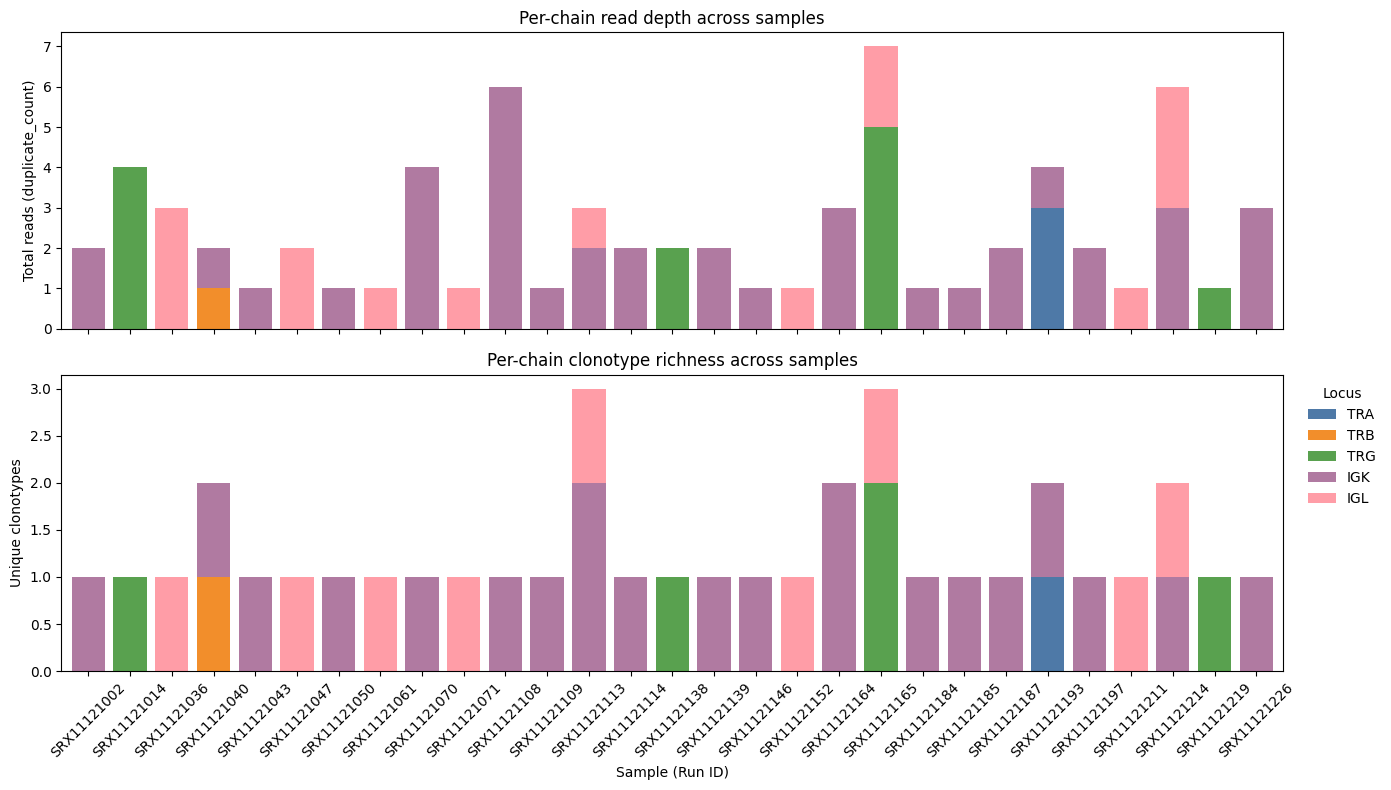

In [12]:
def _pivot(summary: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Pivot *summary* into a wide matrix for stacked-bar plotting."""
    present_loci = [l for l in LOCI_ORDER if l in summary["locus"].unique()]
    return (
        summary
        .pivot_table(index="sample_id", columns="locus", values=value_col, fill_value=0)
        .reindex(columns=present_loci, fill_value=0)
    )


def plot_stacked_bars(
    summary: pd.DataFrame,
    *,
    figsize: tuple[int, int] = (14, 8),
) -> None:
    """Draw two stacked bar charts (reads and clonotypes) side by side.

    Parameters
    ----------
    summary:
        Long-form DataFrame with columns ``sample_id``, ``locus``,
        ``duplicate_count``, ``clonotype_count``.
    figsize:
        Overall figure size ``(width, height)`` in inches.
    """
    reads      = _pivot(summary, "duplicate_count")
    clonotypes = _pivot(summary, "clonotype_count")
    colors     = [LOCI_COLORS[l] for l in reads.columns]

    fig, (ax_reads, ax_clones) = plt.subplots(2, 1, figsize=figsize, sharex=True)

    reads.plot(
        kind="bar", stacked=True, ax=ax_reads,
        color=colors, legend=False, width=0.8,
    )
    ax_reads.set_ylabel("Total reads (duplicate_count)")
    ax_reads.set_title("Per-chain read depth across samples")
    ax_reads.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    clonotypes.plot(
        kind="bar", stacked=True, ax=ax_clones,
        color=colors, legend=True, width=0.8,
    )
    ax_clones.set_ylabel("Unique clonotypes")
    ax_clones.set_title("Per-chain clonotype richness across samples")
    ax_clones.set_xlabel("Sample (Run ID)")
    ax_clones.tick_params(axis="x", rotation=45)
    ax_clones.legend(
        title="Locus", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False
    )

    fig.tight_layout()
    plt.show()


plot_stacked_bars(summary)